# Quantum Mechanical Bootstrap of Polynomial Potentials

## Recurrence Relation

$$ \forall n \in \mathbb{Z}_{\geq 0}$$

 \begin{equation}
     -2n\langle V(x)x^{n-1} \rangle +2nE\langle x^{n-1}\rangle- \frac{n(n-1)(n-2)}{4m} \langle x^{n-3}\rangle + \langle x^{n}V'(x)\rangle = 0
\end{equation}

### Quantum Harmonic Oscillator 

For the Quantum Harmonic Oscillator we have 

$$ V(x) = \frac{1}{2} m\omega^{2} x^{2} $$

Which results in the following recurrence relation, 

\begin{equation}
     -m\omega^{2}n\langle x^{n+1} \rangle +2nE\langle x^{n-1}\rangle- \frac{n(n-1)(n-2)}{4m} \langle x^{n-3}\rangle + m\omega^{2}\langle x^{n+1}\rangle = 0
\end{equation}

We also note that, 

\begin{equation}
    \langle x^{2n+1} \rangle = 0
    \qquad \text{for all } n \in \mathbb{Z}_{\geq 0}.
\end{equation}


In [2]:
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from functools import lru_cache

In [3]:

# ============================================================
# Quantum Harmonic Oscillator Bootstrap
#
# Dimensionless variables:
#
#     q = sqrt(m*omega/hbar) x
#     epsilon = E/(hbar*omega)
#
# Recurrence:
#
#     s <q^s>
#       = 2(s-1) epsilon <q^(s-2)>
#       + [(s-1)(s-2)(s-3)/4] <q^(s-4)>
#
# Odd moments vanish.
# ============================================================


epsilon = sp.Symbol("epsilon", real=True)


# ============================================================
# Data structures
# ============================================================

@dataclass(frozen=True)
class RootBracket:
    lo: sp.Rational
    hi: sp.Rational
    multiplicity: int = 1

    @property
    def midpoint(self):
        return (self.lo + self.hi) / 2

    @property
    def width(self):
        return self.hi - self.lo


@dataclass(frozen=True)
class Boundary:
    kind: str                  # "domain" or "root"
    exact: sp.Rational = None
    root: RootBracket = None

    @property
    def estimate(self):
        if self.kind == "domain":
            return self.exact
        return self.root.midpoint

    @property
    def uncertainty(self):
        if self.kind == "domain":
            return sp.Rational(0)
        return self.root.width / 2


@dataclass(frozen=True)
class AllowedInterval:
    K: int
    left: Boundary
    right: Boundary

    @property
    def midpoint(self):
        return (self.left.estimate + self.right.estimate) / 2

    @property
    def half_width(self):
        return (self.right.estimate - self.left.estimate) / 2

    @property
    def touches_domain(self):
        return (
            self.left.kind == "domain"
            or self.right.kind == "domain"
        )


In [4]:
# ============================================================
# Utilities
# ============================================================

def Q(value):
    """
    Convert a number to an exact SymPy Rational.

    Using the string representation avoids turning
    binary floating-point error into the rational.
    """
    if isinstance(value, sp.Rational):
        return value

    return sp.Rational(str(value))


In [6]:
# ============================================================
# Exact SHO moments
# ============================================================

@lru_cache(maxsize=None)
def sho_moments(K):
    """
    Return exact moments

        mu_s = <q^s>

    for s = 0,...,2K-2.

    A K x K Hankel matrix requires moments through
    order 2K-2.
    """

    if K < 1:
        raise ValueError("K must be >= 1")

    max_power = 2 * K - 2

    mu = [sp.Integer(0)] * (max_power + 1)

    # Normalisation
    mu[0] = sp.Integer(1)

    for s in range(1, max_power + 1):

        # Parity of SHO eigenstates
        if s % 2 == 1:
            mu[s] = sp.Integer(0)
            continue

        # Recurrence
        term = (
            2
            * (s - 1)
            * epsilon
            * mu[s - 2]
        )

        if s >= 4:
            term += (
                sp.Rational(
                    (s - 1) * (s - 2) * (s - 3),
                    4
                )
                * mu[s - 4]
            )

        mu[s] = sp.cancel(term / s)

    return tuple(mu)


In [7]:
# ============================================================
# Hankel / moment matrices
# ============================================================

@lru_cache(maxsize=None)
def parity_blocks(K):
    """
    Construct the even and odd parity Hankel blocks.

    Original basis:

        {1, q, q^2, ..., q^(K-1)}

    Since odd moments vanish, the full Hankel matrix
    decomposes into even and odd sectors.
    """

    mu = sho_moments(K)

    even_powers = list(range(0, K, 2))
    odd_powers  = list(range(1, K, 2))

    M_even = sp.Matrix([
        [mu[i + j] for j in even_powers]
        for i in even_powers
    ])

    M_odd = sp.Matrix([
        [mu[i + j] for j in odd_powers]
        for i in odd_powers
    ])

    return M_even, M_odd


def full_moment_matrix(K):
    """
    Construct the complete K x K moment matrix

        M_ij = <q^(i+j)>.
    """

    mu = sho_moments(K)

    return sp.Matrix([
        [mu[i + j] for j in range(K)]
        for i in range(K)
    ])



In [8]:
# ============================================================
# Exact determinant polynomials
# ============================================================

@lru_cache(maxsize=None)
def determinant_polynomials(K):
    """
    Return the exact determinant polynomials of the
    even and odd parity blocks.
    """

    M_even, M_odd = parity_blocks(K)

    polynomials = []

    for M in (M_even, M_odd):

        if M.rows == 0:
            polynomials.append(
                sp.Poly(1, epsilon, domain=sp.QQ)
            )
            continue

        det = sp.cancel(
            M.det(method="domain-ge")
        )

        numerator, denominator = sp.fraction(det)

        # For SHO the denominator should be a rational
        # constant and therefore irrelevant to zero locations.
        if epsilon in denominator.free_symbols:
            raise RuntimeError(
                "Unexpected epsilon-dependent denominator."
            )

        poly = sp.Poly(
            sp.expand(numerator),
            epsilon,
            domain=sp.QQ
        )

        polynomials.append(poly)

    return polynomials[0], polynomials[1]


@lru_cache(maxsize=None)
def singularity_polynomial(K):
    """
    Product

        det(M_even) det(M_odd).

    Every possible change in matrix inertia must occur
    at a zero of this polynomial.
    """

    P_even, P_odd = determinant_polynomials(K)

    return sp.Poly(
        P_even.as_expr() * P_odd.as_expr(),
        epsilon,
        domain=sp.QQ
    )


In [9]:
# ============================================================
# Exact positive-definiteness tests
# ============================================================

def block_is_positive_definite_exact(M, E):
    """
    Exact Sylvester criterion.

    At a rational energy away from determinant roots,
    the matrix is positive definite iff every leading
    principal minor is strictly positive.
    """

    if M.rows == 0:
        return True

    E = Q(E)

    M_E = M.subs(epsilon, E)

    for n in range(1, M_E.rows + 1):

        minor = M_E[:n, :n]

        determinant = sp.cancel(
            minor.det(method="domain-ge")
        )

        if determinant <= 0:
            return False

    return True


def is_positive_definite_exact(K, E):
    """
    Test both parity sectors exactly.
    """

    M_even, M_odd = parity_blocks(K)

    return (
        block_is_positive_definite_exact(M_even, E)
        and
        block_is_positive_definite_exact(M_odd, E)
    )


In [10]:
# ============================================================
# Exact root isolation
# ============================================================

def isolate_singular_roots(
    K,
    Emin=0,
    Emax=6,
    digits=30
):
    """
    Isolate every real root of

        det(M_even) det(M_odd)

    inside the requested energy domain.

    SymPy returns exact rational brackets around each root.
    """

    Emin = Q(Emin)
    Emax = Q(Emax)

    if Emin >= Emax:
        raise ValueError("Require Emin < Emax")

    P = singularity_polynomial(K)

    # Target width for root-isolation brackets
    tolerance = sp.Rational(
        1,
        10**digits
    )

    root_intervals = sp.polys.polytools.intervals(
        P,
        eps=tolerance
    )

    roots = []

    for interval, multiplicity in root_intervals:

        lo, hi = interval

        lo = sp.Rational(lo)
        hi = sp.Rational(hi)

        # Discard roots outside search region
        if hi <= Emin:
            continue

        if lo >= Emax:
            continue

        roots.append(
            RootBracket(
                lo=lo,
                hi=hi,
                multiplicity=int(multiplicity)
            )
        )

    roots.sort(
        key=lambda r: r.midpoint
    )

    return roots


In [21]:
import time
# ============================================================
# Bootstrap allowed regions
# ============================================================

def allowed_intervals(
    K,
    Emin=0,
    Emax=6,
    root_digits=30
):
    """
    Determine every finite-K bootstrap-allowed energy region.

    No energy grid is used.

    Algorithm
    ---------
    1. Find every determinant zero.
    2. These roots partition the energy axis into cells.
    3. Pick one exact rational point in every cell.
    4. Test moment-matrix positivity exactly.
    5. Merge adjacent allowed cells.

    Since matrix inertia cannot change without an eigenvalue
    crossing zero, one positivity test per cell is sufficient.
    """

    Emin = Q(Emin)
    Emax = Q(Emax)

    roots = isolate_singular_roots(
        K,
        Emin,
        Emax,
        digits=root_digits
    )

    # --------------------------------------------------------
    # Classify every open cell
    # --------------------------------------------------------

    allowed = []

    number_of_cells = len(roots) + 1

    for j in range(number_of_cells):

        if j == 0:
            left = Emin
        else:
            left = roots[j - 1].hi

        if j == len(roots):
            right = Emax
        else:
            right = roots[j].lo

        if left >= right:
            allowed.append(False)
            continue

        # Exact rational test point
        sample = (left + right) / 2

        allowed.append(
            is_positive_definite_exact(K, sample)
        )

    # --------------------------------------------------------
    # Convert positive cells into connected intervals
    # --------------------------------------------------------

    regions = []

    j = 0

    while j < len(allowed):

        if not allowed[j]:
            j += 1
            continue

        start = j

        while (
            j + 1 < len(allowed)
            and allowed[j + 1]
        ):
            j += 1

        end = j

        # Left boundary
        if start == 0:

            left_boundary = Boundary(
                kind="domain",
                exact=Emin
            )

        else:

            left_boundary = Boundary(
                kind="root",
                root=roots[start - 1]
            )

        # Right boundary
        if end == len(roots):

            right_boundary = Boundary(
                kind="domain",
                exact=Emax
            )

        else:

            right_boundary = Boundary(
                kind="root",
                root=roots[end]
            )

        regions.append(
            AllowedInterval(
                K=K,
                left=left_boundary,
                right=right_boundary
            )
        )

        j += 1

    return regions


# ============================================================
# Convert results to Pandas
# ============================================================

def bootstrap_dataframe(
    K,
    Emin=0,
    Emax=6,
    root_digits=30,
    decimal_digits=20
):
    """
    Run the bootstrap and return a tidy Pandas DataFrame.
    """

    regions = allowed_intervals(
        K,
        Emin,
        Emax,
        root_digits
    )

    rows = []

    for level, region in enumerate(regions):

        # Ignore intervals which simply continue to the
        # artificial boundary of our search domain when
        # identifying resolved states.
        rows.append({
            "K": K,
            "level": level,

            "E_lower":
                float(sp.N(
                    region.left.estimate,
                    decimal_digits
                )),

            "E_upper":
                float(sp.N(
                    region.right.estimate,
                    decimal_digits
                )),

            "E_mid":
                float(sp.N(
                    region.midpoint,
                    decimal_digits
                )),

            "half_width":
                float(sp.N(
                    region.half_width,
                    decimal_digits
                )),

            "left_root_uncertainty":
                float(sp.N(
                    region.left.uncertainty,
                    decimal_digits
                )),

            "right_root_uncertainty":
                float(sp.N(
                    region.right.uncertainty,
                    decimal_digits
                )),

            "domain_truncated":
                region.touches_domain
        })

    return pd.DataFrame(rows)


# ============================================================
# Multiple bootstrap depths
# ============================================================

def bootstrap_sequence(
    Ks,
    Emin=0,
    Emax=6,
    root_digits=30
):
    """
    Run several bootstrap truncation orders
    and report computation time for each depth.
    """

    frames = []

    for K in Ks:

        print(f"\nRunning K = {K} ...")

        start = time.perf_counter()

        df = bootstrap_dataframe(
            K,
            Emin,
            Emax,
            root_digits
        )

        elapsed = time.perf_counter() - start

        # Add runtime to results
        df["runtime_seconds"] = elapsed

        frames.append(df)

        print(
            f"K = {K} completed in "
            f"{elapsed:.2f} seconds"
        )

    return pd.concat(
        frames,
        ignore_index=True
    )

# ============================================================
# Plot bootstrap spectrum
# ============================================================

def plot_bootstrap_regions(results):
    """
    Plot allowed energy intervals against bootstrap depth.
    """

    plt.figure(figsize=(10, 6))

    for _, row in results.iterrows():

        plt.plot(
            [row["E_lower"], row["E_upper"]],
            [row["K"], row["K"]],
            linewidth=4
        )

    plt.xlabel(
        r"Dimensionless energy $\epsilon = E/(\hbar\omega)$"
    )

    plt.ylabel(
        r"Bootstrap depth $K$"
    )

    plt.title(
        "Quantum Harmonic Oscillator Moment Bootstrap"
    )

    plt.grid(alpha=0.25)

    plt.show()

In [14]:
for n in range(9):
    display(
        sp.Eq(
            sp.Symbol(fr"\langle q^{n}\rangle"),
            sp.factor(mu[n])
        )
    )

Eq(\langle q^0\rangle, 1)

Eq(\langle q^1\rangle, 0)

Eq(\langle q^2\rangle, epsilon)

Eq(\langle q^3\rangle, 0)

Eq(\langle q^4\rangle, 3*(4*epsilon**2 + 1)/8)

Eq(\langle q^5\rangle, 0)

Eq(\langle q^6\rangle, 5*epsilon*(4*epsilon**2 + 5)/8)

Eq(\langle q^7\rangle, 0)

Eq(\langle q^8\rangle, 35*(16*epsilon**4 + 56*epsilon**2 + 9)/128)


Running K = 6 ...
K = 6 completed in 0.04 seconds

Running K = 8 ...
K = 8 completed in 0.35 seconds

Running K = 10 ...
K = 10 completed in 1.05 seconds

Running K = 12 ...
K = 12 completed in 2.26 seconds

Running K = 14 ...
K = 14 completed in 7.47 seconds

Running K = 16 ...
K = 16 completed in 27.07 seconds


,K,level,E_lower,E_upper,E_mid,half_width,left_root_uncertainty,right_root_uncertainty,domain_truncated,runtime_seconds
0,6,0,0.417458,6.000000,3.208729,2.791271,8.391911e-32,0.000000e+00,True,0.036542
1,8,0,0.480732,0.566508,0.523620,0.042888,4.506511e-31,9.101804e-32,False,0.349769
2,8,1,1.131855,6.000000,3.565927,2.434073,2.317771e-31,0.000000e+00,True,0.349769
3,10,0,0.496654,0.508961,0.502807,0.006153,2.055928e-31,3.516354e-31,False,1.048523
4,10,1,1.367704,1.778062,1.572883,0.205179,1.751618e-31,4.760749e-31,False,1.048523
5,10,2,1.962499,6.000000,3.981250,2.018750,3.701363e-31,0.000000e+00,True,1.048523
6,12,0,0.499492,0.501337,0.500414,0.000923,1.096323e-31,2.744778e-31,False,2.263764
7,12,1,1.456661,1.536297,1.496479,0.039818,3.102268e-31,1.747560e-31,False,2.263764
8,12,2,2.326215,6.000000,4.163107,1.836893,1.836477e-31,0.000000e+00,True,2.263764
9,14,0,0.499927,0.500194,0.500060,0.000133,2.680034e-31,3.082016e-31,False,7.471598


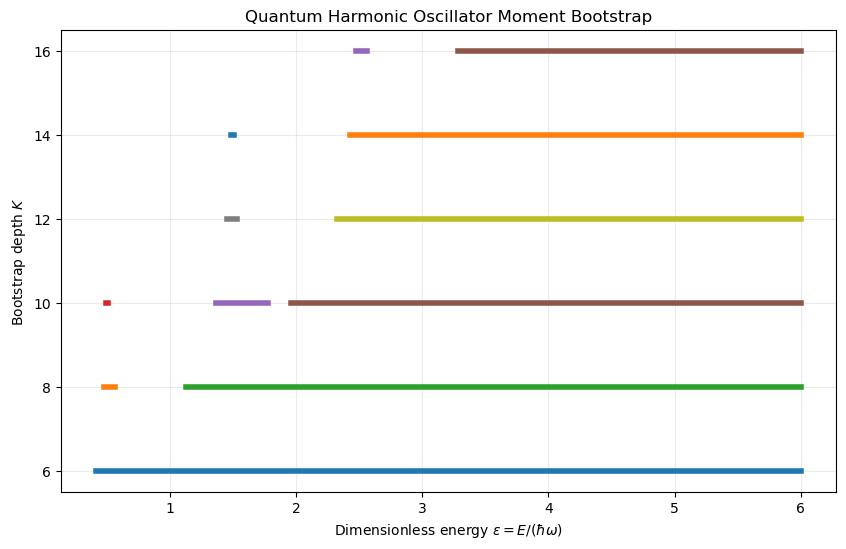

In [22]:
from IPython.display import display

results = bootstrap_sequence(
    Ks=[6, 8, 10, 12, 14, 16],
    Emin=0,
    Emax=6,
    root_digits=30
)

display(results)

plot_bootstrap_regions(results)